In [1]:
import numpy as np

In [2]:
X = np.array([
    [1],
    [2],
    [3],
    [4],
    [5],
    [6],
    [7],
    [8]
])

y = np.array([
    10,
    19,
    32,
    49,
    70,
    95,
    124,
    157
])

In [6]:
from polynomialregression import PolynomialRegressionGD
model = PolynomialRegressionGD(
    degree=2,
    learning_rate=0.001,
    epochs=10000
)

model.fit(X, y)

In [7]:
print("Coefficients:", model.coef_)
print("Intercept:", model.intercept_)

Coefficients: [3.84596222 1.91563428]
Intercept: 3.2532047424187867


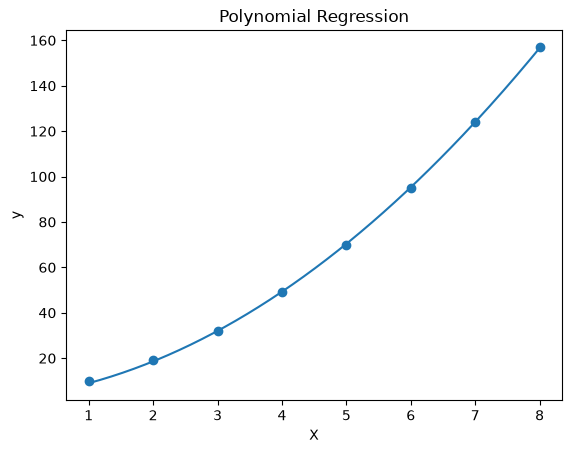

In [14]:
# Visualization

import matplotlib.pyplot as plt

X_plot = np.linspace(
    X.min(),
    X.max(),
    200
).reshape(-1, 1)

y_plot = model.predict(X_plot)

plt.scatter(X, y)

plt.plot(X_plot, y_plot)

plt.xlabel("X")
plt.ylabel("y")
plt.title("Polynomial Regression")

plt.show()

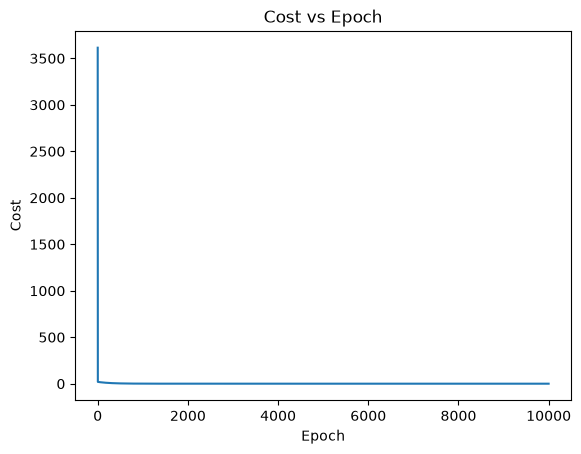

In [9]:
plt.plot(model.cost_history)

plt.xlabel("Epoch")
plt.ylabel("Cost")
plt.title("Cost vs Epoch")

plt.show()

In [10]:
def mean_squared_error(y, y_pred):
    return np.mean((y - y_pred) ** 2)

In [11]:
def root_mean_squared_error(y, y_pred):
    return np.sqrt(mean_squared_error(y, y_pred))

In [12]:
def mean_absolute_error(y, y_pred):
    return np.mean(np.abs(y - y_pred))

In [13]:
def r2_score(y, y_pred):

    ss_res = np.sum((y - y_pred) ** 2)

    ss_tot = np.sum((y - np.mean(y)) ** 2)

    return 1 - (ss_res / ss_tot)

In [15]:
y_pred = model.predict(X)

print("MSE:", mean_squared_error(y, y_pred))
print("RMSE:", root_mean_squared_error(y, y_pred))
print("MAE:", mean_absolute_error(y, y_pred))
print("R²:", r2_score(y, y_pred))

MSE: 0.19724017887336065
RMSE: 0.4441173030555786
MAE: 0.3477178968491601
R²: 0.9999177909017929


In [16]:
# Sklearn Implementation
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

poly = PolynomialFeatures(degree=2)

X_poly = poly.fit_transform(X)

sk_model = LinearRegression()

sk_model.fit(X_poly, y)

sk_pred = sk_model.predict(X_poly)

In [17]:
print("From Scratch:")
print(model.predict(X))

print("\nSklearn:")
print(sk_pred)

From Scratch:
[  9.01480124  18.60766631  32.03179994  49.28720213  70.37387289
  95.29181222 124.04102011 156.62149656]

Sklearn:
[ 10.  19.  32.  49.  70.  95. 124. 157.]


In [23]:
import seaborn as sns
tips = sns.load_dataset('tips')

In [19]:
pip install seaborn

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
Note: you may need to restart the kernel to use updated packages.


In [24]:
tips.head(5)

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [25]:
tips.info()

<class 'pandas.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   total_bill  244 non-null    float64 
 1   tip         244 non-null    float64 
 2   sex         244 non-null    category
 3   smoker      244 non-null    category
 4   day         244 non-null    category
 5   time        244 non-null    category
 6   size        244 non-null    int64   
dtypes: category(4), float64(2), int64(1)
memory usage: 7.4 KB


In [29]:
X_train = tips.drop(columns=['tip'])

In [30]:
Y_train = tips['tip']

In [62]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_train, Y_train, test_size=0.20)

In [63]:
X_train

,total_bill,sex,smoker,day,time,size
10,10.27,1,0,2,0,1
211,25.89,1,1,1,0,3
13,18.43,1,0,2,0,3
58,11.24,1,1,1,0,1
192,28.44,1,1,3,1,1
...,...,...,...,...,...,...
233,10.77,1,0,1,0,1
62,11.02,1,1,1,0,1
128,11.38,0,0,3,1,1
90,28.97,1,1,0,0,1


In [67]:
X_test.head()

,total_bill,sex,smoker,day,time,size
97,12.03,1,1,0,0,1
86,13.03,1,0,3,1,1
221,13.42,0,1,0,1,1
148,9.78,1,0,3,1,1
1,10.34,1,0,2,0,2


In [34]:
tips.columns

Index(['total_bill', 'tip', 'sex', 'smoker', 'day', 'time', 'size'], dtype='str')

In [35]:
tips['sex'].value_counts()

sex
Male      157
Female     87
Name: count, dtype: int64

In [36]:
tips['smoker'].value_counts()

smoker
No     151
Yes     93
Name: count, dtype: int64

In [37]:
tips['day'].value_counts()

day
Sat     87
Sun     76
Thur    62
Fri     19
Name: count, dtype: int64

In [38]:
tips['time'].value_counts()

time
Dinner    176
Lunch      68
Name: count, dtype: int64

In [39]:
tips['size'].value_counts()

size
2    156
3     38
4     37
5      5
1      4
6      4
Name: count, dtype: int64

In [40]:
from sklearn.preprocessing import LabelEncoder
label = LabelEncoder()

In [54]:
for column in tips.columns[2:]:
    X_train[column] = label.fit_transform(tips[column])
    print(column)

sex
smoker
day
time
size


In [68]:
X_train.head(5)

,total_bill,sex,smoker,day,time,size
10,10.27,1,0,2,0,1
211,25.89,1,1,1,0,3
13,18.43,1,0,2,0,3
58,11.24,1,1,1,0,1
192,28.44,1,1,3,1,1


In [56]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [73]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.fit_transform(X_test)

In [79]:
model = PolynomialRegressionGD(
    degree=2,
    learning_rate=0.1,
    epochs=10000
)

model.fit(X_train_scaled, y_train)

In [80]:
y_pred = model.predict(X_test)

print("MSE:", mean_squared_error(y_test, y_pred))
print("RMSE:", root_mean_squared_error(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("R²:", r2_score(y_test, y_pred))

MSE: 827.0937332718231
RMSE: 28.75923735553193
MAE: 24.46674006635944
R²: -370.6129111284665


In [83]:
# Sklearn Implementation
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

poly = PolynomialFeatures(degree=2)

X_poly = poly.fit_transform(X_train_scaled)

sk_model = LinearRegression()

sk_model.fit(X_poly, y_train)

X_poly_test = poly.fit_transform(X_test_scaled)

sk_pred = sk_model.predict(X_poly_test)

In [85]:
print("MSE:", mean_squared_error(y_test, sk_pred))
print("RMSE:", root_mean_squared_error(y_test, sk_pred))
print("MAE:", mean_absolute_error(y_test, sk_pred))
print("R²:", r2_score(y_test, sk_pred))

MSE: 1.1634409640771213
RMSE: 1.0786292060189735
MAE: 0.8413416864275304
R²: 0.4772664013829282
